In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import json
import numpy as np
import scipy.stats as stats

fontsize=16
plt.rc('font', size=fontsize-4)

In [2]:
with open('thresholds.json') as f:
    thresholds = json.load(f)

In [3]:
thresholds

{'transformer': {'mu': [249.2, 674, 1673.6], 'sigma': [8, 14.1, 38.9]},
 'max_conv2d': {'mu': [340.4, 692.6, 1651.1], 'sigma': [40, 60, 80]},
 'full_conv2d': {'mu': [331.6, 694.5, 1681], 'sigma': [40, 60, 80]},
 'full_conv1d': {'mu': [307.1, 716.3, 1626.5], 'sigma': [40, 60, 80]},
 'full_mlp': {'mu': [323.9, 685.8, 1659.9], 'sigma': [40, 60, 80]},
 'slim_conv2d': {'mu': [310.2, 633.5, 1593.4], 'sigma': [40, 60, 80]},
 'slim_conv1d': {'mu': [309.2, 624.3, 1514.9], 'sigma': [40, 60, 80]},
 'slim_mlp': {'mu': [298.5, 592.7, 1479.9], 'sigma': [40, 60, 80]}}

In [4]:
def draw_one_model(m, y, ax):

    y = [-1*y-1]*3

    #ax.errorbar(x=m['mu'],y=y,xerr=m['sigma'],linestyle='')
    dot = ax.scatter(m['mu'], y, marker='v',s=100)

    return [dot]


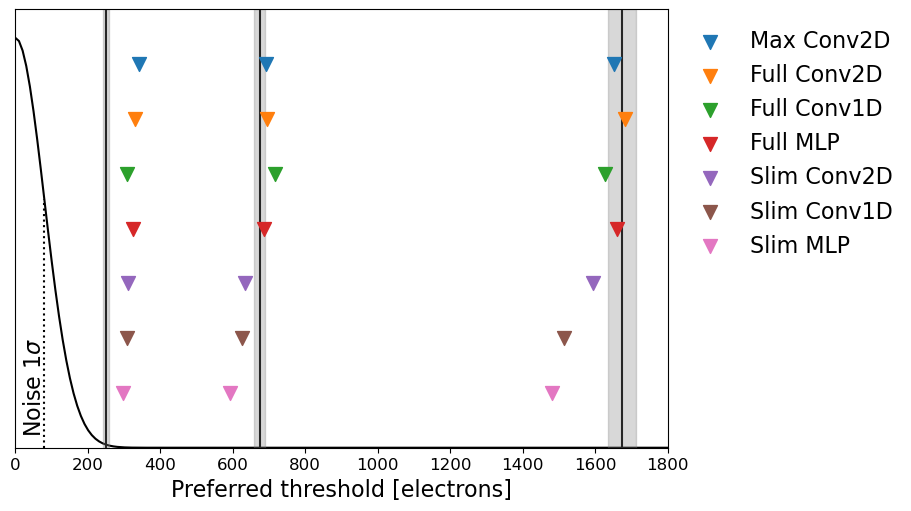

In [5]:
fig, ax = plt.subplots(1,1,figsize=(9,5),sharey=True,constrained_layout=True)

names = {}
names['max_conv2d'] = 'Max Conv2D'
names['full_conv2d'] = 'Full Conv2D'
names['full_conv1d'] = 'Full Conv1D'
names['full_mlp'] = 'Full MLP'
names['slim_conv2d'] = 'Slim Conv2D'
names['slim_conv1d'] = 'Slim Conv1D'
names['slim_mlp'] = 'Slim MLP'

models = ['max_conv2d','full_conv2d','full_conv1d','full_mlp','slim_conv2d','slim_conv1d','slim_mlp']
yspan = [-1*len(models)-1,0]

# Plot the noise
mu = 0
sigma = 80
x = np.linspace(0, 2000, 200)
ax.plot(x, 1500*stats.norm.pdf(x, mu, sigma)-len(models)-1,color='black',zorder=0)
plt.plot([sigma]*2,[-1*len(models)-1,1500*stats.norm.pdf(sigma, mu, sigma)-len(models)-1],color='black',zorder=0,linestyle=':')
ax.text(x=20, y=-7.7, s=r'Noise 1$\sigma$', fontsize=fontsize, rotation='vertical')

# Plot the transformer thresholds
plt.plot([thresholds['transformer']['mu'][0]]*2,yspan,color='black',zorder=0)
plt.fill_between(x=[thresholds['transformer']['mu'][0] - thresholds['transformer']['sigma'][0],
                    thresholds['transformer']['mu'][0] + thresholds['transformer']['sigma'][0]],
                 y1=[-1*len(models)-1,-1*len(models)-1], color='gray', alpha=0.3)

plt.plot([thresholds['transformer']['mu'][1]]*2,yspan,color='black',zorder=0)
plt.fill_between(x=[thresholds['transformer']['mu'][1] - thresholds['transformer']['sigma'][1],
                    thresholds['transformer']['mu'][1] + thresholds['transformer']['sigma'][1]],
                 y1=[-1*len(models)-1,-1*len(models)-1], color='gray', alpha=0.3)

plt.plot([thresholds['transformer']['mu'][2]]*2,yspan,color='black',zorder=0)
plt.fill_between(x=[thresholds['transformer']['mu'][2] - thresholds['transformer']['sigma'][2],
                    thresholds['transformer']['mu'][2] + thresholds['transformer']['sigma'][2]],
                 y1=[-1*len(models)-1,-1*len(models)-1], color='gray', alpha=0.3)

# Loop over the models
dots = []
for i,m in enumerate(models):
    dots += draw_one_model(thresholds[m], i, ax)

plt.legend(dots,[names[l] for l in models],frameon=False,fontsize=fontsize,bbox_to_anchor=[1,1])

plt.xlim(0,1800)
plt.xlabel('Preferred threshold [electrons]',fontsize=fontsize)
plt.ylim(-1*len(models)-1,0)
ax.set_yticks([]);

plt.savefig("plots/thresholds.pdf")
plt.savefig("plots/thresholds.png")